# Task 2: SQL for Data Extraction — Python + SQL Integration
**Dataset:** Netflix Movies & TV Shows (`netflix_movies.csv`)
**Database:** `netflix.db` (SQLite)
**Goal:** Connect Python to the database with `sqlalchemy`, run SQL queries with
`pandas.read_sql()`, and answer 10 business questions.

Internship: Apexplanet | Task 2 of 7-day SQL module


In [1]:
# Setup: connect to the database using SQLAlchemy
# Notebook lives in notebooks/, database lives in ../database/netflix.db
from sqlalchemy import create_engine, text
import pandas as pd

engine = create_engine("sqlite:///../database/netflix.db")

# Quick sanity check
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", engine)


,name
0,netflix_titles
1,netflix_genres
2,netflix_cast


## Business Question 1: What are the top 5 genres by number of titles?

In [2]:
query1 = '''
SELECT g.genre, COUNT(*) AS title_count
FROM netflix_genres g
GROUP BY g.genre
ORDER BY title_count DESC
LIMIT 5;
'''
top_genres = pd.read_sql(query1, engine)
top_genres


,genre,title_count
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869


<Axes: title={'center': 'Top 5 Genres by Title Count'}, ylabel='genre'>

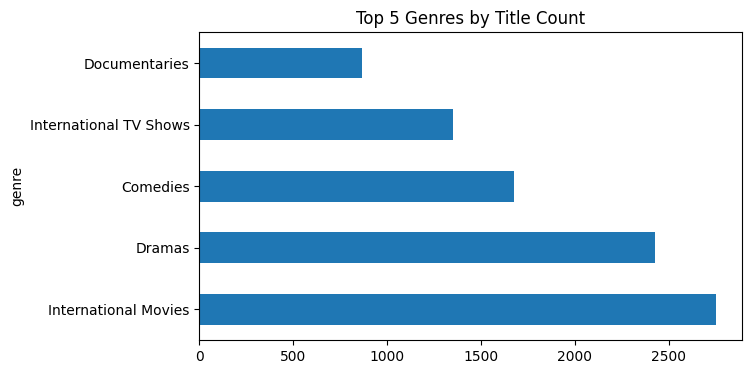

In [3]:
top_genres.plot(kind='barh', x='genre', y='title_count', legend=False,
                 title='Top 5 Genres by Title Count', figsize=(7,4))


## Business Question 2: What is the monthly trend of content added to Netflix?

In [4]:
query2 = '''
SELECT strftime('%Y-%m', date_added) AS month_added, COUNT(*) AS titles_added
FROM netflix_titles
WHERE date_added IS NOT NULL
GROUP BY month_added
ORDER BY month_added;
'''
monthly_trend = pd.read_sql(query2, engine)
monthly_trend.tail(12)


,month_added,titles_added
96,2020-10,167
97,2020-11,154
98,2020-12,169
99,2021-01,132
100,2021-02,109
101,2021-03,112
102,2021-04,188
103,2021-05,132
104,2021-06,207
105,2021-07,257


<Axes: title={'center': 'Monthly Content Additions to Netflix'}, xlabel='month_added'>

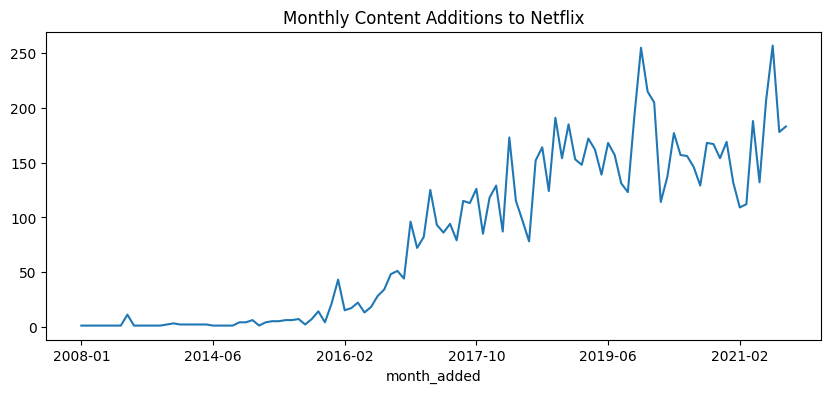

In [5]:
monthly_trend.plot(x='month_added', y='titles_added', figsize=(10,4),
                    title='Monthly Content Additions to Netflix', legend=False)


## Business Question 3: Which countries produce the most content?

In [6]:
query3 = '''
SELECT country, COUNT(*) AS total_titles
FROM netflix_titles
WHERE country != 'Unknown'
GROUP BY country
ORDER BY total_titles DESC
LIMIT 10;
'''
top_countries = pd.read_sql(query3, engine)
top_countries


,country,total_titles
0,United States,2818
1,India,972
2,United Kingdom,419
3,Japan,245
4,South Korea,199
5,Canada,181
6,Spain,145
7,France,124
8,Mexico,110
9,Egypt,106


## Business Question 4: What is the Movie vs TV Show split by release year (last 10 years)?

<Axes: title={'center': 'Movies vs TV Shows by Release Year'}, xlabel='release_year'>

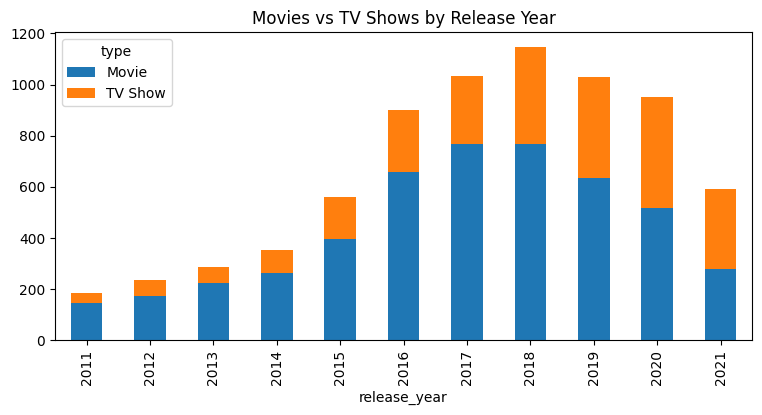

In [7]:
query4 = '''
SELECT release_year, type, COUNT(*) AS total
FROM netflix_titles
WHERE release_year >= (SELECT MAX(release_year) - 10 FROM netflix_titles)
GROUP BY release_year, type
ORDER BY release_year;
'''
movie_vs_tv = pd.read_sql(query4, engine)
movie_vs_tv.pivot(index='release_year', columns='type', values='total').plot(
    kind='bar', stacked=True, figsize=(9,4), title='Movies vs TV Shows by Release Year')


## Business Question 5: Who are the top 10 most-featured actors?

In [8]:
query5 = '''
SELECT actor, COUNT(*) AS appearances
FROM netflix_cast
GROUP BY actor
ORDER BY appearances DESC
LIMIT 10;
'''
top_actors = pd.read_sql(query5, engine)
top_actors


,actor,appearances
0,Shah Rukh Khan,35
1,Julie Tejwani,32
2,Rupa Bhimani,31
3,Anupam Kher,30
4,Akshay Kumar,29
5,Amitabh Bachchan,26
6,Andrea Libman,25
7,Paresh Rawal,24
8,Kareena Kapoor,24
9,Naseeruddin Shah,23


## Business Question 6: How is content rated (audience rating distribution)?

<Axes: title={'center': 'Content Count by Rating'}, xlabel='rating'>

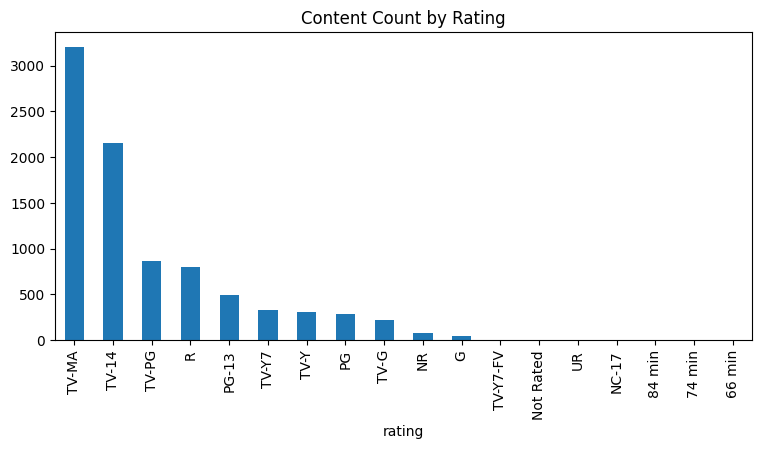

In [9]:
query6 = '''
SELECT rating, COUNT(*) AS total
FROM netflix_titles
GROUP BY rating
ORDER BY total DESC;
'''
rating_dist = pd.read_sql(query6, engine)
rating_dist.plot(kind='bar', x='rating', y='total', legend=False, figsize=(9,4),
                  title='Content Count by Rating')


## Business Question 7: How has average movie duration changed over time?

<Axes: title={'center': 'Average Movie Duration by Release Year'}, xlabel='release_year'>

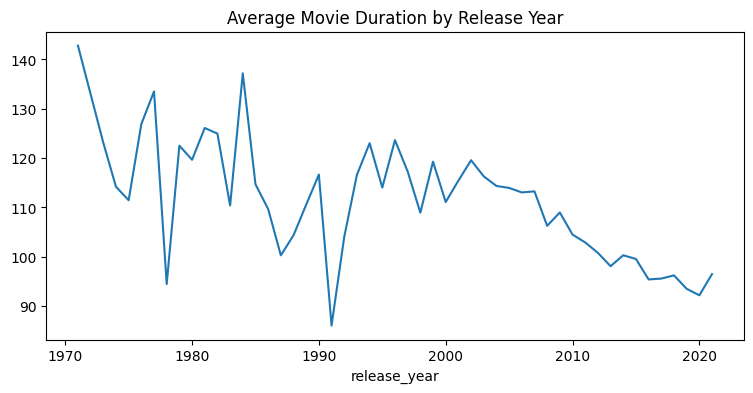

In [10]:
query7 = '''
SELECT release_year, AVG(duration_minutes) AS avg_duration
FROM netflix_titles
WHERE type = 'Movie' AND duration_minutes IS NOT NULL
GROUP BY release_year
HAVING COUNT(*) >= 5
ORDER BY release_year;
'''
avg_duration = pd.read_sql(query7, engine)
avg_duration.plot(x='release_year', y='avg_duration', figsize=(9,4),
                   title='Average Movie Duration by Release Year', legend=False)


## Business Question 8: Which directors have the largest, most consistent catalogs (5+ titles)?

In [11]:
query8 = '''
SELECT director, COUNT(*) AS total_titles,
       GROUP_CONCAT(DISTINCT type) AS content_types
FROM netflix_titles
WHERE director != 'Unknown'
GROUP BY director
HAVING COUNT(*) >= 5
ORDER BY total_titles DESC;
'''
top_directors = pd.read_sql(query8, engine)
top_directors


,director,total_titles,content_types
0,Rajiv Chilaka,19,Movie
1,"Raúl Campos, Jan Suter",18,Movie
2,Suhas Kadav,16,Movie
3,Marcus Raboy,16,"TV Show,Movie"
4,Jay Karas,14,Movie
...,...,...,...
87,Ava DuVernay,5,Movie
88,Anurag Kashyap,5,Movie
89,Antoinette Jadaone,5,Movie
90,Angga Dwimas Sasongko,5,Movie


## Business Question 9: What is the year-over-year growth rate in content additions? (window function via CTE)

In [12]:
query9 = '''
WITH yearly AS (
    SELECT strftime('%Y', date_added) AS year_added, COUNT(*) AS additions
    FROM netflix_titles
    WHERE date_added IS NOT NULL
    GROUP BY year_added
)
SELECT year_added, additions,
       LAG(additions) OVER (ORDER BY year_added) AS prev_year,
       ROUND(100.0 * (additions - LAG(additions) OVER (ORDER BY year_added))
             / LAG(additions) OVER (ORDER BY year_added), 1) AS pct_growth
FROM yearly
ORDER BY year_added;
'''
yoy_growth = pd.read_sql(query9, engine)
yoy_growth


,year_added,additions,prev_year,pct_growth
0,2008,2,NaN,NaN
1,2009,2,2.0,0.0
2,2010,1,2.0,-50.0
3,2011,13,1.0,1200.0
4,2012,3,13.0,-76.9
5,2013,11,3.0,266.7
6,2014,24,11.0,118.2
7,2015,82,24.0,241.7
8,2016,429,82.0,423.2
9,2017,1188,429.0,176.9


## Business Question 10: Using the `v_genre_summary` view — which genres skew most Movie-heavy vs TV-heavy?

In [13]:
query10 = '''
SELECT genre, title_count, movie_count, tv_show_count,
       ROUND(100.0 * movie_count / title_count, 1) AS pct_movie
FROM v_genre_summary
WHERE title_count >= 50
ORDER BY pct_movie DESC;
'''
genre_skew = pd.read_sql(query10, engine)
genre_skew.head(10)


,genre,title_count,movie_count,tv_show_count,pct_movie
0,Action & Adventure,859,859,0,100.0
1,Anime Features,71,71,0,100.0
2,Children & Family Movies,641,641,0,100.0
3,Classic Movies,116,116,0,100.0
4,Comedies,1674,1674,0,100.0
5,Cult Movies,71,71,0,100.0
6,Documentaries,869,869,0,100.0
7,Dramas,2427,2427,0,100.0
8,Faith & Spirituality,65,65,0,100.0
9,Horror Movies,357,357,0,100.0


## Summary of Findings
- International Movies, Dramas, and Comedies are the most common genres on the platform.
- Content additions to Netflix grew sharply through 2018-2020 before leveling off.
- The United States, India, and the United Kingdom are the top content-producing countries.
- Average movie runtimes have gradually shortened in more recent release years.
- A handful of directors (5+ titles) account for a disproportionate share of the catalog, useful for content-partnership analysis.

All queries above are also available as standalone, reusable SQL in `queries.sql`,
and the underlying connection/query logic is centralized in `db_utils.py` for reuse
in any future script or notebook.
